# Cross-check cavity resonance (care) code with LLRFLibsPy library

We check a scenario in which a number of mechanical modes detune the resonance frequency of a superconducting cavity. With beam loading activated, it is more straightforward to cross-check results using the same sampling time. This time defaults to 1 microsecond.

In [1]:
# --! import Python libraries

import numpy as np
from matplotlib import pyplot as plt

from scipy.signal import decimate

# --! import LLRFLibsPy package

from llrflibs.rf_sim import cav_ss_mech, sim_scav_step
from llrflibs.rf_control import ss_discrete

# --! import CARE package

import care_control
import care_sim


In [2]:
# --! define total duration of simulation --!

t_dur = 20e-3 # 20 ms

### Run cavity simulation using LLRFLibsPy

This code is mostly taken from an example found in LLRFLibsPy repo found on GitHub.

In [3]:
# --! simulate

# parameters
Ts  = 1e-6                  # electrical model sampling time, s
mds = 1                     # down-sampling for mech model
Tsm = Ts * mds              # mech model sampling time, s

# define the mechanical modes and descritize the model
mech_modes = {'f': [280, 341, 460, 487, 618],
              'Q': [40, 20, 50, 80, 100],
              'K': [2, 0.8, 2, 0.6, 0.2]}

status, Am, Bm, Cm, Dm = cav_ss_mech(mech_modes)
status, Ad, Bd, Cd, Dd, _ = ss_discrete(Am, Bm, Cm, Dm, 
                                     Ts     = Tsm, 
                                     method = 'zoh', 
                                     plot   = False,
                                     plot_pno = 10000)

# define a cavity
f0      = 1.3e9                                 # RF operating frequency, Hz
roQ     = 1036                                  # r/Q of the cavity, Ohm
QL      = 3e6                                   # loaded quality factor
wh      = np.pi * f0 / QL                       # half bandwidth, rad/s
RL      = 0.5 * roQ * QL                        # loaded resistance (Linac convention), Ohm
ig      = 0.016                                 # RF drive power equivalent current, A
ib      = 0.008                                 # average beam current, A
t_fill  = 510                                   # length of cavity filling period, sample
t_flat  = 1300                                  # end time of the flattop period, sample
dw0     = 2*np.pi*000                           # initial detuning, rad/s

N   = int(t_dur / Ts)
print(f'number of simulation steps for llrflibspy is {N}')
vc_sig1  = np.zeros(N, dtype = complex)
vf  = np.zeros(N, dtype = complex)
vr  = np.zeros(N, dtype = complex)
vb  = np.zeros(N, dtype = complex)
dw_sig1  = np.zeros(N) 

vf[:] = RL * ig * 0.1                           # define forward drive
vb[7_500:12_500] = -RL * ib * 0.1               # define beam drive

state_m  = np.matrix(np.zeros(Bd.shape))        # state of the mechanical equation
state_vc = 0.0                                  # state of cavity equation
dw_step0 = 0.0

for i in range(N):
    status, vc_new, vr_new, dw_new, state_m = sim_scav_step( wh, 
                                                          dw_step0,
                                                          dw0, 
                                                          vf[i], 
                                                          vb[i], 
                                                          state_vc, 
                                                          Ts, 
                                                          beta      = 1e4,
                                                          state_m0  = state_m, 
                                                          Am        = Ad, 
                                                          Bm        = Bd, 
                                                          Cm        = Cd, 
                                                          Dm        = Dd,
                                                          mech_exe  = True)

    vc_sig1[i] = vc_new if np.isscalar(vc_new) else vc_new[0,0]
    dw_sig1[i] = dw_new[0,0]
    state_vc = vc_sig1[i]
    dw_step0 = dw_sig1[i]
    


number of simulation steps for llrflibspy is 20000


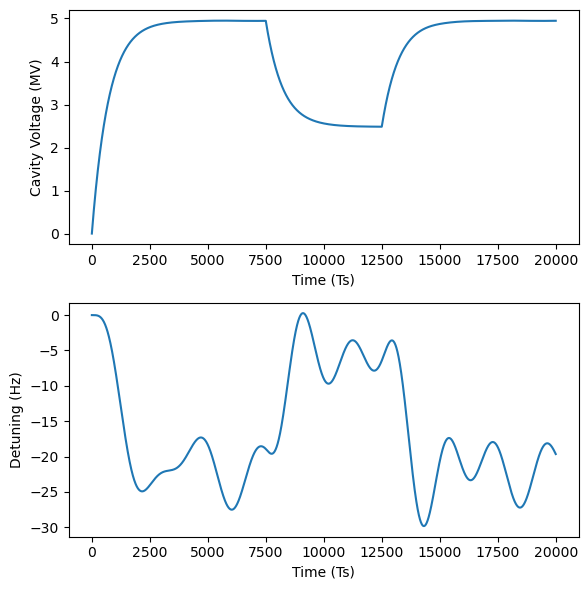

In [4]:
plt.figure(figsize=(6, 6))

plt.subplot(2,1,1)
plt.plot(abs(vc_sig1) * 1e-6)
plt.xlabel('Time (Ts)')
plt.ylabel('Cavity Voltage (MV)')

plt.subplot(2,1,2)
plt.plot(dw_sig1 / 2 / np.pi)
plt.xlabel('Time (Ts)')
plt.ylabel('Detuning (Hz)')

plt.tight_layout()
plt.show()

### Run cavity simulation using CARE

In [5]:
me = care_control.create_matrices_elec(f0, QL)
mm = care_control.create_matrices_mech(np.array(mech_modes['f']), np.array(mech_modes['Q']), np.array(mech_modes['K']))


In [6]:
dt          = 1e-6
sim_nsample = int(t_dur / dt)
print(f'number of simulation steps for care is {sim_nsample}')

vc_sig2  = np.zeros(sim_nsample, dtype = complex)
vf_sig  = np.zeros(sim_nsample, dtype = complex)
vr_sig  = np.zeros(sim_nsample, dtype = complex)
vb_sig  = np.zeros(sim_nsample, dtype = complex)
dw_sig2  = np.zeros(sim_nsample)

vc = 0.0
sm = np.zeros(mm.b.shape)


number of simulation steps for care is 20000


In [7]:

for i in range(sim_nsample):

    vc, dc, sm = care_sim.step_cav(vc, vf[i], sm, me, mm, dt=dt, vb=vb[i])

    vc_sig2[i] = vc
    dw_sig2[i] = dc


### Compare results of both packages

In case different sampling time is used, there is a need for downsampling. But as was mentioned in the beginning, for beam loading we use the same sampling time to run both codes.

downsample factor is 1


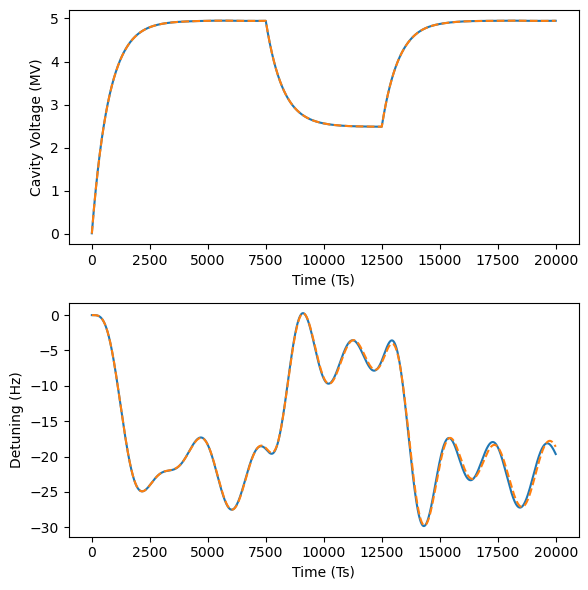

In [8]:
downsample_factor = int(N / sim_nsample)
print(f'downsample factor is {downsample_factor}')
vc_sig1_down = vc_sig1[::downsample_factor]
dw_sig1_down = dw_sig1[::downsample_factor]

plt.figure(figsize=(6, 6))

plt.subplot(2,1,1)
plt.plot((abs(vc_sig1_down) * 1e-6)[1:])
plt.plot(abs(vc_sig2) * 1e-6, linestyle='dashed')
plt.xlabel('Time (Ts)')
plt.ylabel('Cavity Voltage (MV)')

plt.subplot(2,1,2)
plt.plot((dw_sig1_down / 2 / np.pi)[1:])
plt.plot(dw_sig2 / 2 / np.pi, linestyle='dashed')
plt.xlabel('Time (Ts)')
plt.ylabel('Detuning (Hz)')

plt.tight_layout()
plt.show()